# KV Cache Selective Recompute

In [ ]:
import numpy as np
from transformers import AutoTokenizer
from numpy.linalg import norm
from scipy import spatial
import matplotlib.pyplot as plt
import os

In [ ]:
kv_recomp = np.load("./saved_kv/recompute.npy")
kv_reuse = np.load("./saved_kv/reuse.npy")
kv_selective = np.load("./saved_kv/selective.npy")
input_ids = np.load("./saved_kv/input_ids.npy").tolist()
print(kv_recomp.shape, kv_reuse.shape, kv_selective.shape)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-32B-Instruct", local_files_only=True)
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", local_files_only=True)

In [ ]:
def cos_distance(vec1: np.ndarray, vec2: np.ndarray):
    return spatial.distance.cosine(vec1, vec2)

def l2_distance(vec1: np.ndarray, vec2: np.ndarray):
    return norm(vec1 - vec2)

In [ ]:
def calc_kv_distance(kv1, kv2, layer, korv, seq, head, metric):
    kv1 = kv1[layer, korv, seq, head]
    kv2 = kv2[layer, korv, seq, head]
    dis = np.zeros((kv2.shape[0],))
    for i, (vec1, vec2) in enumerate(zip(kv1, kv2)):
        dis[i] = metric(vec1, vec2)
    return dis

In [ ]:
layer, korv, head, metric = 2, 0, 0, l2_distance
plt.figure(figsize=(12,3))
dis1 = calc_kv_distance(kv_recomp, kv_reuse, layer, korv, 0, head, metric)
plt.plot(dis1, label="Reuse Difference")
dis2 = calc_kv_distance(kv_recomp, kv_selective, layer, korv, 0, head, metric)
plt.plot(dis2, label="EPIC-8 Difference")
plt.legend(loc="upper right")
plt.show()

In [ ]:
def topk_numpy(arr,k,dim):
    idx = np.argpartition(-arr, kth=k, axis=dim)
    idx = idx.take(indices=range(k), axis=dim)
    val = np.take_along_axis(arr, indices=idx, axis=dim)
    sorted_idx = np.argsort(-val, axis=dim)
    idx = np.take_along_axis(idx, indices=sorted_idx, axis=dim)
    val = np.take_along_axis(val, indices=sorted_idx, axis=dim)
    return val, idx.astype(dtype=int)

val, idx = topk_numpy(dis2, 100, 0)
for i in idx[0:40]:
    print(f'{i}:{repr(tokenizer.decode(input_ids[i:i+1]))}')

In [ ]:
def plot_3d_kvcache_distance(cache1, cache2, metric, korv, head=0, interval=6, figname=None):
    ax = plt.figure(figsize=(20,12)).add_subplot(projection='3d')
    ax.set_box_aspect((40, 20, 16))
    ax.view_init(elev=15, azim=-80, roll=0)
    colors = plt.colormaps['viridis_r'](np.linspace(0, 1, cache1.shape[0]))
    seq_len = cache1.shape[4]
    x_indices = list(range(seq_len))
    for layer_i in reversed(range(1, cache1.shape[0], interval)):
        ax.plot(
            x_indices, 
            [layer_i] * seq_len, 
            calc_kv_distance(cache1, cache2, layer_i, korv, 0, head, metric),
            color=colors[layer_i],
        )
    if figname is not None:
        plt.savefig(os.path.join("figures", figname))
    plt.show()

In [ ]:
plot_3d_kvcache_distance(kv_recomp, kv_selective, l2_distance, 0, figname="llama3.1_8b-selective.png")
plot_3d_kvcache_distance(kv_recomp, kv_reuse, l2_distance, 0, figname="llama3.1_8b-reuse.png")

In [ ]:
def calc_norm_ratio(kv1, kv2, korv, head):
    kv1 = kv1[:, korv, 0, head]
    kv2 = kv2[:, korv, 0, head]
    kv1_norm = norm(kv1, axis=-1)
    kv2_norm = norm(kv2, axis=-1)
    ratio = kv1_norm / kv2_norm
    return ratio

In [ ]:
ratio = calc_norm_ratio(kv_recomp, kv_selective, 0, 0)
layer_num, seq_len = ratio.shape
# 计算每个随机变量的均值和标准差
variable_means = np.mean(ratio, axis=1)
variable_stds = np.std(ratio, axis=1)
# 创建图形
plt.figure(figsize=(12, 3))
# 绘制误差棒（用"I"图样标出一个标准差）
plt.errorbar(range(layer_num), variable_means, yerr=variable_stds, 
             fmt='o',  # 不显示数据点，因为我们后面会画折线
             capsize=5,  # 误差棒端帽长度
             capthick=2,  # 误差棒端帽粗细
             elinewidth=2,  # 误差棒线宽
             color='red',  # 误差棒颜色
             alpha=0.7,  # 透明度
             label='1 stddev')
# 绘制平均值点的折线图
plt.plot(range(layer_num), variable_means, 
         marker='o',  # 数据点标记
         markersize=8,  # 标记大小
         linewidth=2,  # 线宽
         color='blue',  # 线条颜色
         label='avg')

plt.xticks(range(layer_num), [f'{i+1}' for i in range(layer_num)])
# 添加网格
plt.grid(True, alpha=0.3, linestyle='--')
# 添加图例
plt.legend(fontsize=10)
# 调整布局
plt.tight_layout()
# 显示图形
plt.savefig(os.path.join("figures", "norm_ratio-qwen3-32b_3.png"))
plt.show()
# np.save("./saved_kv/qwen3-4b_layer-recover.npy", variable_means)

# 高德数据集

In [ ]:
import os
import numpy as np
from collections import Counter
from python.inference.mdocdataset import load_mdoc_dataset
import matplotlib.pyplot as plt

# amapdata = load_mdoc_dataset(
#     "amap", 
#     "../datasets/AmapData.csv",
#     load_full=True
# )
amapdata = load_mdoc_dataset(
    "musique", 
    "../datasets/musique_ans_v1.0_train.jsonl",
)
# amapdata = load_mdoc_dataset("longalpaca", "../datasets/longalpaca_prompts.txt")
print(len(amapdata))

In [ ]:
for sample in amapdata:
    if sample['qid'] == 'e207f0cd648c4dd4516b519a490faacd3dae921aac636340':
        break
# sample = amapdata[100]
with open('./saved_kv/sample.txt', 'w') as f:
    # f.write(sample['system_prompt'] + '\n========\n'.join(sample['documents']) + sample['question'] + sample['answer'][0])
    f.write('\n========\n'.join(sample['documents']) + sample['question'] + sample['answer'][0])

In [ ]:
def plot_hist_and_stat(doc_lengths, num_bins, title, xlabel):
    # 绘制直方图
    plt.figure(figsize=(6, 2))
    plt.hist(doc_lengths, bins=num_bins, alpha=0.7, color='steelblue')
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

    max_doc_length = max(doc_lengths)
    max_doc_index = doc_lengths.index(max_doc_length)

    # 打印基本统计信息
    print(f"Mean: {np.mean(doc_lengths):.2f}")
    print(f"Std: {np.std(doc_lengths):.2f}")
    print(f"Min: {min(doc_lengths)}")
    print(f"Max: {max(doc_lengths)}")


# 获取所有sample的documents数量
doc_lengths = [len(sample['documents']) for sample in amapdata]
plot_hist_and_stat(doc_lengths, max(doc_lengths), "Number of Documents per Sample", "Number of Documents")

# 获取所有sample的documents长度
doc_lengths = []
for sample in amapdata:
    doc_lengths.extend(map(len, sample['documents']))
plot_hist_and_stat(doc_lengths, 50, "Distribution of Documents Length", "Length of Documents")

# 获取所有sample长度
doc_lengths = [
    len(sample['system_prompt']) + sum(map(len, sample['documents'])) + len(sample['question'])
    # sum(map(len, sample['documents'])) + len(sample['question'])
    for sample in amapdata
]
plot_hist_and_stat(doc_lengths, 50, "Distribution of Sample Length", "Length of Sample")

In [ ]:
# for i, sample in enumerate(amapdata):
#     if sample['qid'] == '21474b8617603387413106658d04e6':
#         max_doc_index = i
with open('saved_kv/sample.txt', 'w') as f:
    sample = amapdata[0]
    f.write(sample['qid'] + '\n\n')
    f.write(sample['system_prompt'])
    f.write('\n'.join(sample['documents']))
    f.write(sample['question'])
    f.write(sample['answer'][0])

In [ ]:
def get_reusable(dataset):
    doc_dict = {}
    for sample in dataset:
        for doc in sample['documents']:
            doc_dict[doc] = doc_dict.get(doc, 0) + 1
    return doc_dict, sum(doc_dict.values())

doc_dict, doc_num = get_reusable(amapdata)
doc_resuable = sum(v - 1 for v in doc_dict.values())
unique_prompts = len(set(sample['system_prompt'] for sample in amapdata))
print("Unique Prompts:", unique_prompts)
print("Total Documents:", doc_num)
print("Unique Documents:", len(doc_dict))
print("Reusable Documents:", doc_resuable)
print("Reusable Rate:", round(doc_resuable / doc_num, 4))

resuable_freq = [(k, v) for k, v in Counter(doc_dict.values()).items()]
# sort by key
resuable_freq.sort(key=lambda x: x[0])
print(resuable_freq)

In [ ]:
for k, v in doc_dict.items():
    if v == 3:
        print(len(k))
        print(k)

# LLM Judge

In [ ]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

judge_scores = np.load("results/amap/llm_judge/score.npz")
print(judge_scores.files)

In [ ]:
def plot_multiple_rating_distributions(ratings_arrays, labels=None, title="Rating Distribution", save_path=None, figsize=(5, 3)):
    if isinstance(ratings_arrays, np.ndarray):
        ratings_arrays = [ratings_arrays]
    if labels is None:
        labels = [f'Dataset {i+1}' for i in range(len(ratings_arrays))]
    fig, ax = plt.subplots(figsize=figsize)
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'lightpink']
    for i, (ratings, label) in enumerate(zip(ratings_arrays, labels)):
        if len(ratings) == 0:
            continue
        rating_counts = Counter(ratings)
        all_ratings = [1, 2, 3, 4, 5]
        counts = [rating_counts.get(r, 0) for r in all_ratings]
        percentages = [count / len(ratings) * 100 if len(ratings) > 0 else 0 for count in counts]
        x_pos = [r + (i - len(ratings_arrays)/2 + 0.5) * 0.2 for r in all_ratings]
        ax.bar(x_pos, percentages, width=0.2, alpha=0.7, label=label, 
               color=colors[i % len(colors)])
    ax.set_xlabel('Rating')
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_labels = ['fullreuse', 'epic16', 'recompute', 'cacheblend']
plot_arrays = [judge_scores[label] for label in plot_labels]
plot_multiple_rating_distributions(plot_arrays, plot_labels)
# print statistics
for label, array in zip(plot_labels, plot_arrays):
    print(f"{label}: {np.mean(array):.6f}")

## 画 Gist Token 实验结果

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd
from pathlib import Path

def plot_gist_results(dataset: str, save_prefix: str = "gist"):
    # 读取实验结果json文件
    with open(f'results/gist/evaluate_checkpoints_{dataset}.jsonl', 'r') as f:  # 请将'experiment_results.json'替换为你的文件路径
        results = [json.loads(line) for line in f]

    def get_baseline(dataset, method):
        with open(f'results/{dataset}/qwen3-4b_{method}_summary.json', 'r') as f: 
            results = json.load(f)
        return round(results["exact_match"], 6)

    # 定义baseline参考线数值（请根据实际情况修改）
    methods = ["reuse", "epic8", "fr", "blend"]
    baselines = {method: get_baseline(dataset, method) for method in methods}

    # 提取模型根目录并组织数据
    model_data = {}

    for result in results:
        model_path = result["model"]
        # 提取根目录模型名称（例如：qwen3-4b-inst/compressed_sft-16x）
        path_parts = model_path.split('/')
        if len(path_parts) >= 2:
            # 获取倒数第二层和最后一层作为模型标识
            root_model = f"{path_parts[-3]}/{path_parts[-2]}" if len(path_parts) >= 3 else f"{path_parts[-2]}"
            
            if root_model not in model_data:
                model_data[root_model] = []
            
            # 从model路径中提取checkpoint步数
            checkpoint_match = re.search(r'checkpoint-(\d+)', model_path)
            if checkpoint_match:
                steps = int(checkpoint_match.group(1))
                model_data[root_model].append({
                    'steps': steps,
                    'score': result['score'],
                    'model': model_path
                })

    model_names_sorted = sorted(model_data.keys())
    # print('\n'.join(model_names_sorted))
    model_avg_scores = []

    # 对每个模型的数据按steps排序，并计算最大step
    for model_name in model_names_sorted:
        model_data[model_name].sort(key=lambda x: x['steps'])
        # 计算相对进度（当前step / 最大step）
        if model_data[model_name]:  # 如果有数据
            max_step = max(item['steps'] for item in model_data[model_name])
            for item in model_data[model_name]:
                item['relative_progress'] = item['steps'] / max_step
        # 计算平均分
        model_avg_scores.append((
            model_name, 
            round(np.mean([item['score'] for item in model_data[model_name]]), 6)
        ))

    # only plot the 10 best models
    model_avg_scores.sort(key=lambda x: x[1], reverse=True)
    plot_model_names = [name for name, _ in model_avg_scores[:10]]

    # 绘制图表
    plt.figure(figsize=(7, 6))

    # 为每个模型绘制一条线
    colors = plt.cm.tab10(range(len(model_data)))  # 使用不同的颜色
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # 不同的标记

    for idx, model_name in enumerate(plot_model_names):
        data_list = model_data[model_name]
        if len(data_list) > 0:  # 只绘制有数据的模型
            df = pd.DataFrame(data_list)
            color = colors[idx % len(colors)]
            marker = markers[idx % len(markers)]
            
            plt.plot(df['relative_progress'], df['score'], 
                    marker=marker, linewidth=2, markersize=8, 
                    label=model_name, color=color)
            
            # 在图上显示具体的数值点
            for i, row in df.iterrows():
                plt.annotate(f'{row["score"]:.3f}', 
                            (row['relative_progress'], row['score']),
                            textcoords="offset points", 
                            xytext=(0,10), 
                            ha='center', 
                            fontsize=8,
                            color=color)

    # 添加baseline参考线
    baseline_colors = plt.cm.tab10(range(len(baselines)))
    for idx, (method, baseline_value) in enumerate(baselines.items()):
        plt.axhline(y=baseline_value, color=baseline_colors[idx % len(baseline_colors)], linestyle='--', linewidth=2, 
                label=f'{method} ({baseline_value})')

    plt.xlabel('Training Progress (current step / max step)', fontsize=12)
    plt.ylabel('Test Score', fontsize=12)
    plt.title('Test Score vs Training Progress by Model', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.8, 1.05), loc='upper right', fontsize=10)

    # 设置x轴为0-1范围
    plt.xlim(0.15, 1.05)
    plt.xticks([0.2, 0.4, 0.6, 0.8, 1.0])

    # 设置图表样式
    # plt.tight_layout()
    plt.savefig(f'figures/{save_prefix}_{dataset}.png', dpi=300, bbox_inches='tight')
    plt.show()


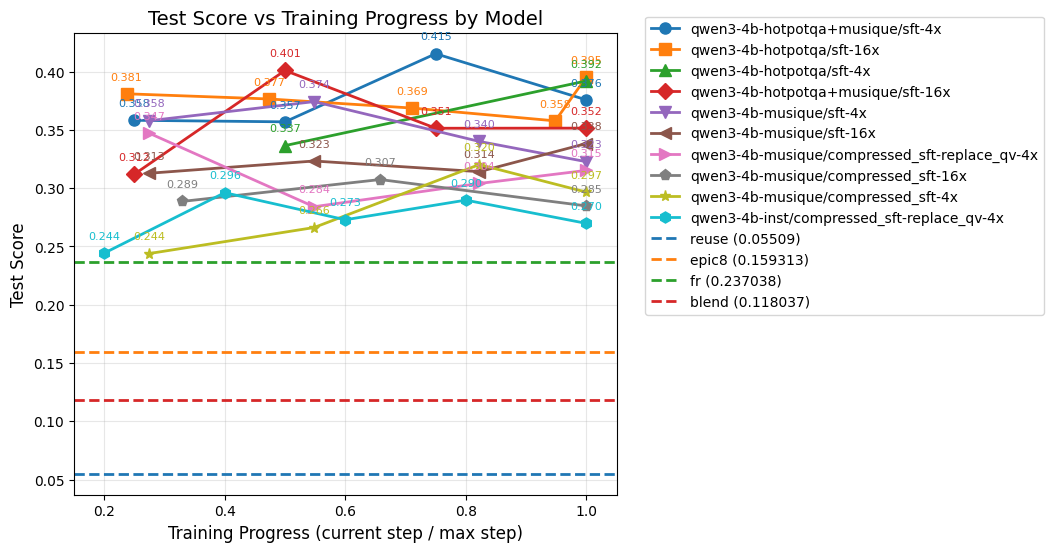

In [7]:
plot_gist_results("wikimqa")

In [8]:
import datasets
data = datasets.load_dataset("json", data_files=['../datasets/musique_ans_v1.0_train.jsonl'])['train']

/home/admin/miniconda3/envs/kvcache/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
data[0]

{'id': '2hop__482757_12019',
 'paragraphs': [{'idx': 0,
   'title': 'Pakistan Super League',
   'paragraph_text': 'Pakistan Super League (Urdu: پاکستان سپر لیگ \u202c \u200e; PSL) is a Twenty20 cricket league, founded in Lahore on 9 September 2015 with five teams and now comprises six teams. Instead of operating as an association of independently owned teams, the league is a single entity in which each franchise is owned and controlled by investors.',
   'is_supporting': False},
  {'idx': 1,
   'title': 'Serena Wilson',
   'paragraph_text': 'Serena Wilson (August 8, 1933 – June 17, 2007), often known just as "Serena", was a well-known dancer, choreographer, and teacher who helped popularize belly dance in the United States. Serena\'s work also helped legitimize the dance form and helped it to be perceived as more than burlesque or stripping. Serena danced in clubs in her younger years, opened her own studio, hosted her own television show, founded her own dance troupe, and was the auth